# Adversarial Robustness Research Series

## Experiment 03a Evasion Attack on Sentiment Analysis with Hugging Face

This notebook is part of a continuous AI security experimentation track.

* Experiment 01: Adversarial Examples in Practice
* Experiment 02: Defending Against Adversarial Attacks
* Experiment 03a: Evasion Attack on Sentiment Analysis with Hugging Face
* Experiment 03b: Evasion Attack on Sentiment Analysis with Local Llama
* Experiment 04: Prompt Injection and RAG Hijacking

## Objective

This notebook demonstrates how a Hugging Face sentiment analysis model can be fooled by small text perturbations.
We start with a clean baseline, then we apply simple evasion attacks, and finally we test a small defensive preprocessing layer.

## Target model

We use a Hugging Face text classification model for sentiment analysis.
The goal is not to build the strongest classifier possible.
The goal is to study how prediction stability changes when the input text is slightly manipulated.

## Notebook structure

1. Step 0  Environment setup
2. Step 1  Hugging Face Hub exploration
3. Step 2  Mini sentiment dataset
4. Step 3  Baseline sentiment pipeline
5. Step 4  Clean baseline evaluation
6. Step 5  Evasion attack generation
7. Step 6  Vulnerable model evaluation on attacked texts
8. Step 7  Defensive preprocessing
9. Step 8  Final comparison
10. Step 9  Security takeaways

## Step 0  Environment setup

This notebook assumes that `transformers`, `torch`, `pandas`, `matplotlib`, and `huggingface_hub` are available in the Python environment.

If needed, uncomment the installation lines below.

In [1]:
# !pip install transformers torch pandas matplotlib huggingface_hub

import os
import re
import sys
import json
import random
import platform
import multiprocessing

import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
except Exception as e:
    torch = None
    print("Torch import error:", e)

try:
    from huggingface_hub import HfApi, model_info
except Exception as e:
    HfApi = None
    model_info = None
    print("huggingface_hub import error:", e)

try:
    from transformers import pipeline
except Exception as e:
    pipeline = None
    print("transformers import error:", e)

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("Pandas version:", pd.__version__)
print("Torch available:", torch is not None)
print("Transformers pipeline available:", pipeline is not None)
print("Hugging Face Hub available:", HfApi is not None)

c:\Users\natyn\anaconda3\envs\ai-sec-research\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
Pandas version: 3.0.1
Torch available: True
Transformers pipeline available: True
Hugging Face Hub available: True


In [4]:
# CPU / GPU detection and thread configuration

num_threads = multiprocessing.cpu_count()

os.environ["OMP_NUM_THREADS"] = str(num_threads)
os.environ["MKL_NUM_THREADS"] = str(num_threads)

gpu_available = False
device_name = "CPU"

if torch is not None and torch.cuda.is_available():
    gpu_available = True
    device_name = torch.cuda.get_device_name(0)

print("CPU threads detected:", num_threads)
print("GPU available:", gpu_available)
print("Using device:", device_name)

print("Optimal threads configured for this machine")

CPU threads detected: 16
GPU available: False
Using device: CPU
Optimal threads configured for this machine


### Output explanation

The cells above verify that the notebook environment is ready.

We check:

1. Python and package availability
2. CPU thread configuration
3. GPU availability for faster inference if CUDA is present

If `transformers` and `huggingface_hub` are available, we can continue with Hugging Face exploration and model inference.

## Step 1  Hugging Face Hub exploration

Before choosing a model, we explore the Hugging Face Hub to identify a few sentiment analysis candidates.
This follows the same logic as the school notebook (Swiss Cyber Institute), but we keep only the parts that are useful for the security experiment.

In [5]:
api = HfApi() if HfApi is not None else None

candidate_models = []

if api is not None:
    search_results = api.list_models(
        filter="text-classification",
        search="sentiment",
        sort="downloads",
        direction=-1,
        limit=10
    )

    for model in search_results:
        candidate_models.append({
            "model_id": model.id,
            "downloads": getattr(model, "downloads", None),
            "likes": getattr(model, "likes", None),
            "pipeline_tag": getattr(model, "pipeline_tag", None)
        })

candidate_models_df = pd.DataFrame(candidate_models)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
candidate_models_df

c:\Users\natyn\anaconda3\envs\ai-sec-research\Lib\site-packages\huggingface_hub\utils\_deprecation.py:100: FutureWarning: Deprecated argument(s) used in 'list_models': direction. Will not be supported from version '1.5'.

Sorting is always descending.
  warnings.warn(message, FutureWarning)


,model_id,downloads,likes,pipeline_tag
0,cardiffnlp/twitter-roberta-base-sentiment-latest,3100108,782,text-classification
1,nlptown/bert-base-multilingual-uncased-sentiment,1295504,466,text-classification
2,finiteautomata/beto-sentiment-analysis,1161972,35,text-classification
3,lxyuan/distilbert-base-multilingual-cased-sentiments-student,982844,308,text-classification
4,cardiffnlp/twitter-xlm-roberta-base-sentiment,852845,254,text-classification
5,bardsai/finance-sentiment-ja-base,768689,3,text-classification
6,cardiffnlp/twitter-roberta-base-sentiment,607799,333,text-classification
7,pysentimiento/robertuito-sentiment-analysis,497974,97,text-classification
8,blanchefort/rubert-base-cased-sentiment-rusentiment,423013,15,text-classification
9,mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis,308859,447,text-classification


### Output explanation and Model Choice

This table shows a few sentiment related models from the Hugging Face Hub.

For this notebook, we want a model that is:

1. easy to load with `pipeline`
2. widely used
3. clearly documented
4. appropriate for English sentiment classification

A strong default choice is usually a DistilBERT or BERT model fine tuned on SST 2.
*SST2= Stanford Sentiment Treebank 2 (NLP Dataset for Sentiment analysis)

But, as the goal is to keep the experiment reproducible and consistent with the Hugging Face exploration step, we now select one model from the candidate list above.

BERT is a Google Model, RoBERTa is a BERT version optomized for Facebook
- trained for a longer time  
- trained on larger datasets  
- removes the Next Sentence Prediction (NSP) objective  
- uses improved data sampling strategies  
As a result:

- it generally outperforms BERT  
- especially on standard NLP tasks such as text classification and sentiment analysis  

In [6]:
MODEL_ID = "cardiffnlp/twitter-roberta-base-sentiment-latest"

model_metadata = None

if model_info is not None:
    try:
        info = model_info(MODEL_ID)
        model_metadata = {
            "model_id": info.id,
            "pipeline_tag": info.pipeline_tag,
            "downloads": getattr(info, "downloads", None),
            "likes": getattr(info, "likes", None),
            "sha": getattr(info, "sha", None),
            "tags_preview": info.tags[:10] if getattr(info, "tags", None) else []
        }
    except Exception as e:
        model_metadata = {"error": str(e)}

model_metadata

{'model_id': 'cardiffnlp/twitter-roberta-base-sentiment-latest',
 'pipeline_tag': 'text-classification',
 'downloads': 3100108,
 'likes': 782,
 'sha': '3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7',
 'tags_preview': ['transformers',
  'pytorch',
  'tf',
  'roberta',
  'text-classification',
  'en',
  'dataset:tweet_eval',
  'arxiv:2202.03829',
  'license:cc-by-4.0',
  'endpoints_compatible']}

### Output explanation

We inspect the selected model in more detail to justify the choice.

Here the selected model is:

`cardiffnlp/twitter-roberta-base-sentiment-latest`

This is a practical choice because:

1. it is widely used for real world sentiment analysis tasks  
2. it is trained on Twitter data, making it robust to noisy and informal text  
3. it is based on RoBERTa, an improved variant of BERT  
4. it provides a more realistic attack surface compared to clean academic datasets  

This makes it particularly relevant for evaluating evasion attacks in practical scenarios.

## Step 2  Mini sentiment dataset

To keep the experiment fully understandable, we build a small labeled dataset directly inside the notebook.

Label convention used in this notebook:

* POSITIVE
* NEGATIVE

The dataset is intentionally simple.
This is not a benchmark notebook.
It is a security robustness notebook.

In [7]:
sentiment_samples = [
    {"sample_id": "S01", "text": "I absolutely loved this movie, it was brilliant and inspiring.", "gold_label": "POSITIVE"},
    {"sample_id": "S02", "text": "The service was excellent and the staff were very kind.", "gold_label": "POSITIVE"},
    {"sample_id": "S03", "text": "This product works perfectly and I am very happy with it.", "gold_label": "POSITIVE"},
    {"sample_id": "S04", "text": "What a fantastic experience, I would gladly recommend it.", "gold_label": "POSITIVE"},
    {"sample_id": "S05", "text": "The update is great, fast, and surprisingly reliable.", "gold_label": "POSITIVE"},
    {"sample_id": "S06", "text": "I hated this film, it was boring and a complete waste of time.", "gold_label": "NEGATIVE"},
    {"sample_id": "S07", "text": "The meal was cold, tasteless, and very disappointing.", "gold_label": "NEGATIVE"},
    {"sample_id": "S08", "text": "This app is frustrating, buggy, and difficult to use.", "gold_label": "NEGATIVE"},
    {"sample_id": "S09", "text": "Customer support was rude and did not solve my issue.", "gold_label": "NEGATIVE"},
    {"sample_id": "S10", "text": "The hotel room was dirty and the stay was unpleasant.", "gold_label": "NEGATIVE"}
]

baseline_df = pd.DataFrame(sentiment_samples)
baseline_df

,sample_id,text,gold_label
0,S01,"I absolutely loved this movie, it was brilliant and inspiring.",POSITIVE
1,S02,The service was excellent and the staff were very kind.,POSITIVE
2,S03,This product works perfectly and I am very happy with it.,POSITIVE
3,S04,"What a fantastic experience, I would gladly recommend it.",POSITIVE
4,S05,"The update is great, fast, and surprisingly reliable.",POSITIVE
5,S06,"I hated this film, it was boring and a complete waste of time.",NEGATIVE
6,S07,"The meal was cold, tasteless, and very disappointing.",NEGATIVE
7,S08,"This app is frustrating, buggy, and difficult to use.",NEGATIVE
8,S09,Customer support was rude and did not solve my issue.,NEGATIVE
9,S10,The hotel room was dirty and the stay was unpleasant.,NEGATIVE


### Output explanation

This DataFrame contains the clean reference texts used in the experiment.

Each row contains:

1. a sample identifier
2. the clean text
3. the expected sentiment label

We keep the dataset small on purpose so that every result remains easy to inspect manually.

## Step 3  Baseline sentiment pipeline

We now load the Hugging Face pipeline and verify that the model can classify clean examples correctly.

In [8]:
clf = None

if pipeline is not None:
    clf = pipeline(
        task="sentiment-analysis",
        model=MODEL_ID
    )

print("Pipeline ready:", clf is not None)
print("Selected model:", MODEL_ID)

c:\Users\natyn\anaconda3\envs\ai-sec-research\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\natyn\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 32067.52it/s]
Robe

Pipeline ready: True
Selected model: cardiffnlp/twitter-roberta-base-sentiment-latest


In [14]:
def predict_sentiment(text):
    result = clf(text)[0]

    normalized_label = result["label"].upper()

    return {
        "pred_label": normalized_label,
        "pred_score": float(result["score"])
    }

quick_test_texts = [
    "I love this product.",
    "This is terrible.",
    "The overall experience was wonderful.",
    "I regret buying this."
]

quick_test_results = []

for text in quick_test_texts:
    pred = predict_sentiment(text)

    quick_test_results.append({
        "text": text,
        "pred_label": pred["pred_label"],
        "pred_score": round(pred["pred_score"], 4)
    })

pd.DataFrame(quick_test_results)

,text,pred_label,pred_score
0,I love this product.,POSITIVE,0.9842
1,This is terrible.,NEGATIVE,0.9146
2,The overall experience was wonderful.,POSITIVE,0.9807
3,I regret buying this.,NEGATIVE,0.8975


### Output explanation

This quick test confirms that the pipeline is operational.

At this point we only verify that:

1. the model loads correctly
2. it returns a label
3. it returns a confidence score

The confidence score is useful later because some evasion attacks do not necessarily flip the final label but may still weaken confidence.

## Step 4  Clean baseline evaluation

We now evaluate the selected model on the clean dataset before applying any attack.

In [15]:
def evaluate_dataframe(input_df, text_column):
    rows = []

    for _, row in input_df.iterrows():
        pred = predict_sentiment(row[text_column])

        rows.append({
            "sample_id": row["sample_id"],
            "text": row[text_column],
            "gold_label": row["gold_label"],
            "pred_label": pred["pred_label"],
            "pred_score": pred["pred_score"],
            "correct": pred["pred_label"] == row["gold_label"]
        })

    return pd.DataFrame(rows)

clean_eval_df = evaluate_dataframe(baseline_df, "text")
clean_eval_df

,sample_id,text,gold_label,pred_label,pred_score,correct
0,S01,"I absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,POSITIVE,0.987775,True
1,S02,The service was excellent and the staff were very kind.,POSITIVE,POSITIVE,0.974857,True
2,S03,This product works perfectly and I am very happy with it.,POSITIVE,POSITIVE,0.989512,True
3,S04,"What a fantastic experience, I would gladly recommend it.",POSITIVE,POSITIVE,0.986201,True
4,S05,"The update is great, fast, and surprisingly reliable.",POSITIVE,POSITIVE,0.983862,True
5,S06,"I hated this film, it was boring and a complete waste of time.",NEGATIVE,NEGATIVE,0.946395,True
6,S07,"The meal was cold, tasteless, and very disappointing.",NEGATIVE,NEGATIVE,0.935271,True
7,S08,"This app is frustrating, buggy, and difficult to use.",NEGATIVE,NEGATIVE,0.950432,True
8,S09,Customer support was rude and did not solve my issue.,NEGATIVE,NEGATIVE,0.907285,True
9,S10,The hotel room was dirty and the stay was unpleasant.,NEGATIVE,NEGATIVE,0.929144,True


In [16]:
clean_accuracy = clean_eval_df["correct"].mean()

clean_summary = pd.DataFrame([
    {
        "setting": "clean baseline",
        "num_samples": len(clean_eval_df),
        "accuracy": round(clean_accuracy, 4),
        "avg_confidence": round(clean_eval_df["pred_score"].mean(), 4)
    }
])

clean_summary

,setting,num_samples,accuracy,avg_confidence
0,clean baseline,10,1.0,0.9591


### Output explanation

This is the clean reference performance.

Important points:

1. accuracy tells us how well the model behaves before the attack
2. average confidence gives a baseline confidence level
3. this clean evaluation becomes the reference point for the rest of the notebook

If the baseline is already weak, it becomes harder to interpret the attack results.
That is why we start here.

## Step 5  Evasion attack generation

We create simple text perturbations that try to preserve the human meaning while making the model less stable.

These attacks are intentionally lightweight and easy to understand:

1. typo injection
2. repeated letters
3. punctuation noise
4. casing noise
5. simple sentiment word masking

In [ ]:
def attack_typo_injection(text):
    replacements = {
        "love": "loove",
        "loved": "luvved",
        "great": "gr8",
        "excellent": "exxcellent",
        "terrible": "terribl3",
        "boring": "boooring",
        "disappointing": "disapp0inting",
        "dirty": "d1rty",
        "kind": "kiind",
        "happy": "hapy"
    }

    attacked_text = text

    for old, new in replacements.items():# Use regex to replace whole words only, ignoring case
        attacked_text = re.sub(rf"\b{re.escape(old)}\b", new, attacked_text, flags=re.IGNORECASE)

    return attacked_text

def attack_repeated_punctuation(text):
    attacked_text = text
    attacked_text = attacked_text.replace(".", " !!!")
    attacked_text = attacked_text.replace(",", " ,,, ")
    return attacked_text

def attack_casing_noise(text):# Alternate casing for each word
    words = text.split()
    transformed_words = []

    for index, word in enumerate(words):
        if index % 2 == 0:
            transformed_words.append(word.upper())
        else:
            transformed_words.append(word.lower())

    return " ".join(transformed_words)

def attack_word_masking(text):
    replacements = {
        "brilliant": "b---liant",
        "inspiring": "insp!ring",
        "excellent": "e.....lent",
        "fantastic": "fan_tastic",
        "boring": "b-----g",
        "waste": "w***e",
        "rude": "r_de",
        "dirty": "d_rty",
        "unpleasant": "unplea_ant"
    }

    attacked_text = text

    for old, new in replacements.items():
        attacked_text = re.sub(rf"\b{re.escape(old)}\b", new, attacked_text, flags=re.IGNORECASE)

    return attacked_text

def attack_combo(text):
    text = attack_typo_injection(text)
    text = attack_repeated_punctuation(text)
    text = attack_casing_noise(text)
    text = attack_word_masking(text)
    return text

In [18]:
attack_df = baseline_df.copy()

attack_df["attack_typo"] = attack_df["text"].apply(attack_typo_injection)
attack_df["attack_punct"] = attack_df["text"].apply(attack_repeated_punctuation)
attack_df["attack_case"] = attack_df["text"].apply(attack_casing_noise)
attack_df["attack_mask"] = attack_df["text"].apply(attack_word_masking)
attack_df["attack_combo"] = attack_df["text"].apply(attack_combo)

attack_preview_df = attack_df[[
    "sample_id",
    "text",
    "attack_typo",
    "attack_punct",
    "attack_case",
    "attack_mask",
    "attack_combo"
]]

attack_preview_df.head(5)

,sample_id,text,attack_typo,attack_punct,attack_case,attack_mask,attack_combo
0,S01,"I absolutely loved this movie, it was brilliant and inspiring.","I absolutely luvved this movie, it was brilliant and inspiring.","I absolutely loved this movie ,,, it was brilliant and inspiring !!!","I absolutely LOVED this MOVIE, it WAS brilliant AND inspiring.","I absolutely loved this movie, it was b---liant and insp!ring.","I absolutely LUVVED this MOVIE ,,, IT was b---liant and insp!ring !!!"
1,S02,The service was excellent and the staff were very kind.,The service was exxcellent and the staff were very kiind.,The service was excellent and the staff were very kind !!!,THE service WAS excellent AND the STAFF were VERY kind.,The service was e.....lent and the staff were very kind.,THE service WAS exxcellent AND the STAFF were VERY kiind !!!
2,S03,This product works perfectly and I am very happy with it.,This product works perfectly and I am very hapy with it.,This product works perfectly and I am very happy with it !!!,THIS product WORKS perfectly AND i AM very HAPPY with IT.,This product works perfectly and I am very happy with it.,THIS product WORKS perfectly AND i AM very HAPY with IT !!!
3,S04,"What a fantastic experience, I would gladly recommend it.","What a fantastic experience, I would gladly recommend it.","What a fantastic experience ,,, I would gladly recommend it !!!","WHAT a FANTASTIC experience, I would GLADLY recommend IT.","What a fan_tastic experience, I would gladly recommend it.","WHAT a fan_tastic experience ,,, i WOULD gladly RECOMMEND it !!!"
4,S05,"The update is great, fast, and surprisingly reliable.","The update is gr8, fast, and surprisingly reliable.","The update is great ,,, fast ,,, and surprisingly reliable !!!","THE update IS great, FAST, and SURPRISINGLY reliable.","The update is great, fast, and surprisingly reliable.","THE update IS gr8 ,,, fast ,,, and SURPRISINGLY reliable !!!"


### Output explanation

This preview lets us compare the clean text with several attacked variants.

The idea is important:

the text should remain mostly understandable to a human,
but the string presented to the model becomes noisier.

That is exactly the type of evasion scenario we want to study.

## Step 6  Vulnerable model evaluation on attacked texts

We now test how the same model behaves when the input is perturbed.

In [61]:
attack_columns = [
    "attack_typo",
    "attack_punct",
    "attack_case",
    "attack_mask",
    "attack_combo"
]

attack_eval_rows = []

for _, row in attack_df.iterrows():
    clean_pred = predict_sentiment(row["text"])

    for attack_name in attack_columns:
        attacked_pred = predict_sentiment(row[attack_name])

        attack_eval_rows.append({
            "sample_id": row["sample_id"],
            "gold_label": row["gold_label"],
            "clean_text": row["text"],
            "attack_name": attack_name,
            "attacked_text": row[attack_name],
            "clean_pred_label": clean_pred["pred_label"],
            "clean_pred_score": clean_pred["pred_score"],
            "attacked_pred_label": attacked_pred["pred_label"],
            "attacked_pred_score": attacked_pred["pred_score"],
            "label_flipped_vs_clean": attacked_pred["pred_label"] != clean_pred["pred_label"],
            "attacked_correct": attacked_pred["pred_label"] == row["gold_label"]
        })

attack_eval_df = pd.DataFrame(attack_eval_rows)
attack_eval_df.head(10)

,sample_id,gold_label,clean_text,attack_name,attacked_text,clean_pred_label,clean_pred_score,attacked_pred_label,attacked_pred_score,label_flipped_vs_clean,attacked_correct
0,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_typo,"I absolutely luvved this movie, it was brilliant and inspiring.",POSITIVE,0.987775,POSITIVE,0.987783,False,True
1,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_punct,"I absolutely loved this movie ,,, it was brilliant and inspiring !!!",POSITIVE,0.987775,POSITIVE,0.990353,False,True
2,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_case,"I absolutely LOVED this MOVIE, it WAS brilliant AND inspiring.",POSITIVE,0.987775,POSITIVE,0.986926,False,True
3,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_mask,"I absolutely loved this movie, it was b---liant and insp!ring.",POSITIVE,0.987775,POSITIVE,0.987838,False,True
4,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_combo,"I absolutely LUVVED this MOVIE ,,, IT was b---liant and insp!ring !!!",POSITIVE,0.987775,POSITIVE,0.987585,False,True
5,S02,POSITIVE,The service was excellent and the staff were very kind.,attack_typo,The service was exxcellent and the staff were very kiind.,POSITIVE,0.974857,POSITIVE,0.969460,False,True
6,S02,POSITIVE,The service was excellent and the staff were very kind.,attack_punct,The service was excellent and the staff were very kind !!!,POSITIVE,0.974857,POSITIVE,0.984801,False,True
7,S02,POSITIVE,The service was excellent and the staff were very kind.,attack_case,THE service WAS excellent AND the STAFF were VERY kind.,POSITIVE,0.974857,POSITIVE,0.978380,False,True
8,S02,POSITIVE,The service was excellent and the staff were very kind.,attack_mask,The service was e.....lent and the staff were very kind.,POSITIVE,0.974857,POSITIVE,0.958921,False,True
9,S02,POSITIVE,The service was excellent and the staff were very kind.,attack_combo,THE service WAS exxcellent AND the STAFF were VERY kiind !!!,POSITIVE,0.974857,POSITIVE,0.981036,False,True


In [64]:
attack_summary_df = attack_eval_df.groupby("attack_name").agg(
    num_samples=("sample_id", "count"),
    attacked_accuracy=("attacked_correct", "mean"),
    flip_rate_vs_clean=("label_flipped_vs_clean", "mean"),
    avg_attacked_confidence=("attacked_pred_score", "mean")
).reset_index()

attack_summary_df["attacked_accuracy"] = attack_summary_df["attacked_accuracy"].round(4)
attack_summary_df["flip_rate_vs_clean"] = attack_summary_df["flip_rate_vs_clean"].round(4)
attack_summary_df["avg_attacked_confidence"] = attack_summary_df["avg_attacked_confidence"].round(4)

attack_summary_df

,attack_name,num_samples,attacked_accuracy,flip_rate_vs_clean,avg_attacked_confidence
0,attack_case,10,1.0,0.0,0.9676
1,attack_combo,10,1.0,0.0,0.9646
2,attack_mask,10,1.0,0.0,0.9198
3,attack_punct,10,1.0,0.0,0.9691
4,attack_typo,10,1.0,0.0,0.9554


In [65]:
comparison_examples = attack_eval_df[
    attack_eval_df["label_flipped_vs_clean"] == True
][[
    "sample_id",
    "gold_label",
    "attack_name",
    "clean_text",
    "attacked_text",
    "clean_pred_label",
    "attacked_pred_label",
    "clean_pred_score",
    "attacked_pred_score"
]]

comparison_examples.head(10)

,sample_id,gold_label,attack_name,clean_text,attacked_text,clean_pred_label,attacked_pred_label,clean_pred_score,attacked_pred_score


### Output explanation

This section is the core of the experiment.

We are looking at three things:

1. attacked accuracy  
   how often the model is still correct after perturbation

2. flip rate versus clean prediction  
   how often the prediction changes when compared with the clean input

3. confidence degradation  
   whether the model becomes less certain under attack

>  <font color='green'>Attack 1:   
A successful evasion attack does not always need a dramatic change.  
Sometimes reducing confidence or increasing instability is already meaningful.  
Not all perturbations are effective evasion attacks.</font>

## Step 6b Strong evasion attacks

We now test how the same model behaves when the input is perturbed(strongee attack).

In [67]:
def attack_negation(text):
    return "I do not think that " + text

def attack_sentiment_flip(text):
    return text + " but actually it was terrible"

def attack_conflict(text):
    return text + " although I hated it"

def attack_sarcasm(text):
    return "Yeah right... " + text

attack_df["attack_negation"] = attack_df["text"].apply(attack_negation)
attack_df["attack_flip"] = attack_df["text"].apply(attack_sentiment_flip)
attack_df["attack_conflict"] = attack_df["text"].apply(attack_conflict)
attack_df["attack_sarcasm"] = attack_df["text"].apply(attack_sarcasm)

In [68]:
attack_df["attack_negation"] = attack_df["text"].apply(attack_negation)
attack_df["attack_flip"] = attack_df["text"].apply(attack_sentiment_flip)
attack_df["attack_conflict"] = attack_df["text"].apply(attack_conflict)
attack_df["attack_sarcasm"] = attack_df["text"].apply(attack_sarcasm)

attack_df[[
    "sample_id",
    "attack_negation",
    "attack_flip",
    "attack_conflict",
    "attack_sarcasm"
]].head()

,sample_id,attack_negation,attack_flip,attack_conflict,attack_sarcasm
0,S01,"I do not think that I absolutely loved this movie, it was brilliant and inspiring.","I absolutely loved this movie, it was brilliant and inspiring. but actually it was terrible","I absolutely loved this movie, it was brilliant and inspiring. although I hated it","Yeah right... I absolutely loved this movie, it was brilliant and inspiring."
1,S02,I do not think that The service was excellent and the staff were very kind.,The service was excellent and the staff were very kind. but actually it was terrible,The service was excellent and the staff were very kind. although I hated it,Yeah right... The service was excellent and the staff were very kind.
2,S03,I do not think that This product works perfectly and I am very happy with it.,This product works perfectly and I am very happy with it. but actually it was terrible,This product works perfectly and I am very happy with it. although I hated it,Yeah right... This product works perfectly and I am very happy with it.
3,S04,"I do not think that What a fantastic experience, I would gladly recommend it.","What a fantastic experience, I would gladly recommend it. but actually it was terrible","What a fantastic experience, I would gladly recommend it. although I hated it","Yeah right... What a fantastic experience, I would gladly recommend it."
4,S05,"I do not think that The update is great, fast, and surprisingly reliable.","The update is great, fast, and surprisingly reliable. but actually it was terrible","The update is great, fast, and surprisingly reliable. although I hated it","Yeah right... The update is great, fast, and surprisingly reliable."


In [69]:
attack_columns = [
    "attack_typo",
    "attack_punct",
    "attack_case",
    "attack_mask",
    "attack_combo",
    "attack_negation",
    "attack_flip",
    "attack_conflict",
    "attack_sarcasm"
]

In [ ]:
# Re-run evaluation with updated attack_columns

attack_eval_rows = []

for _, row in attack_df.iterrows():
    clean_pred = predict_sentiment(row["text"])

    for attack_name in attack_columns:
        attacked_pred = predict_sentiment(row[attack_name])

        attack_eval_rows.append({
            "sample_id": row["sample_id"],
            "gold_label": row["gold_label"],
            "clean_text": row["text"],
            "attack_name": attack_name,
            "attacked_text": row[attack_name],
            "clean_pred_label": clean_pred["pred_label"],
            "clean_pred_score": clean_pred["pred_score"],
            "attacked_pred_label": attacked_pred["pred_label"],
            "attacked_pred_score": attacked_pred["pred_score"],
            "label_flipped_vs_clean": attacked_pred["pred_label"] != clean_pred["pred_label"],
            "attacked_correct": attacked_pred["pred_label"] == row["gold_label"]
        })

attack_eval_df = pd.DataFrame(attack_eval_rows)

def highlight_confidence_drop(row):
    clean = row["clean_pred_score"]
    attacked = row["attacked_pred_score"]
    
    # seuil de chute significative (à ajuster si besoin)
    if attacked < clean - 0.2:
        return ['border: 3px solid red'] * len(row)
    else:
        return [''] * len(row)

attack_eval_df.head(10).style.apply(highlight_confidence_drop, axis=1)

,sample_id,gold_label,clean_text,attack_name,attacked_text,clean_pred_label,clean_pred_score,attacked_pred_label,attacked_pred_score,label_flipped_vs_clean,attacked_correct
0,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_typo,"I absolutely luvved this movie, it was brilliant and inspiring.",POSITIVE,0.987775,POSITIVE,0.987783,False,True
1,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_punct,"I absolutely loved this movie ,,, it was brilliant and inspiring !!!",POSITIVE,0.987775,POSITIVE,0.990353,False,True
2,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_case,"I absolutely LOVED this MOVIE, it WAS brilliant AND inspiring.",POSITIVE,0.987775,POSITIVE,0.986926,False,True
3,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_mask,"I absolutely loved this movie, it was b---liant and insp!ring.",POSITIVE,0.987775,POSITIVE,0.987838,False,True
4,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_combo,"I absolutely LUVVED this MOVIE ,,, IT was b---liant and insp!ring !!!",POSITIVE,0.987775,POSITIVE,0.987585,False,True
5,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_negation,"I do not think that I absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.987775,POSITIVE,0.878141,False,True
6,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_flip,"I absolutely loved this movie, it was brilliant and inspiring. but actually it was terrible",POSITIVE,0.987775,POSITIVE,0.625127,False,True
7,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_conflict,"I absolutely loved this movie, it was brilliant and inspiring. although I hated it",POSITIVE,0.987775,POSITIVE,0.955128,False,True
8,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_sarcasm,"Yeah right... I absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.987775,POSITIVE,0.987970,False,True
9,S02,POSITIVE,The service was excellent and the staff were very kind.,attack_typo,The service was exxcellent and the staff were very kiind.,POSITIVE,0.974857,POSITIVE,0.969460,False,True


: 

>  <font color='orange'>Attack 2: the confidence rate fell, the model is now unstable but the attack didn't succed yet.</font>


### Step 6c Stronger evasion attack

n the previous step, we observed that:

- surface-level perturbations did not change the model prediction
- semantic perturbations reduced confidence but did not flip the label

This means the model is **robust to noise**, but still **vulnerable to stronger semantic manipulation**.

We now introduce stronger attacks designed to override the original sentiment.

These attacks aim to:
1. dominate the semantic meaning of the sentence
2. shift the model decision boundary
3. force a prediction flip

This step is critical because a successful evasion attack requires an actual label change, not just instability.  
  <font color='red'>These attacks simulate more realistic adversarial inputs where an attacker injects strong sentiment signals to manipulate the model output.</font>


In [ ]:
#attack_fun
def attack_targeted_semantic_override(text, gold_label):
    if gold_label == "POSITIVE":
        return "I hated it. It was awful, frustrating, disappointing, and a complete waste of time."
    else:
        return "I loved it. It was excellent, wonderful, inspiring, and absolutely worth it."

def attack_targeted_verdict(text, gold_label):
    if gold_label == "POSITIVE":
        return "Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing."
    else:
        return "Final verdict: POSITIVE. Excellent, pleasant, great, and satisfying."

In [ ]:
#apply targeted semantic override and verdict attacks

attack_df["attack_targeted_override"] = attack_df.apply(
    lambda row: attack_targeted_semantic_override(row["text"], row["gold_label"]),
    axis=1
)

attack_df["attack_targeted_verdict"] = attack_df.apply(
    lambda row: attack_targeted_verdict(row["text"], row["gold_label"]),
    axis=1
)

attack_df[[
    "sample_id",
    "gold_label",
    "text",
    "attack_targeted_override",
    "attack_targeted_verdict"
]].head()

,sample_id,gold_label,text,attack_targeted_override,attack_targeted_verdict
0,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.","I hated it. It was awful, frustrating, disappointing, and a complete waste of time.","Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing."
1,S02,POSITIVE,The service was excellent and the staff were very kind.,"I hated it. It was awful, frustrating, disappointing, and a complete waste of time.","Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing."
2,S03,POSITIVE,This product works perfectly and I am very happy with it.,"I hated it. It was awful, frustrating, disappointing, and a complete waste of time.","Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing."
3,S04,POSITIVE,"What a fantastic experience, I would gladly recommend it.","I hated it. It was awful, frustrating, disappointing, and a complete waste of time.","Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing."
4,S05,POSITIVE,"The update is great, fast, and surprisingly reliable.","I hated it. It was awful, frustrating, disappointing, and a complete waste of time.","Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing."


In [ ]:
# Update attack_columns to include the new attacks
attack_columns = [
    "attack_typo",
    "attack_punct",
    "attack_case",
    "attack_mask",
    "attack_combo",
    "attack_negation",
    "attack_flip",
    "attack_conflict",
    "attack_sarcasm",
    "attack_targeted_override",
    "attack_targeted_verdict"
]

In [45]:
# Re-run evaluation with updated attack_columns
attack_eval_rows = []

for _, row in attack_df.iterrows():
    clean_pred = predict_sentiment(row["text"])

    for attack_name in attack_columns:
        attacked_pred = predict_sentiment(row[attack_name])

        attack_eval_rows.append({
            "sample_id": row["sample_id"],
            "gold_label": row["gold_label"],
            "clean_text": row["text"],
            "attack_name": attack_name,
            "attacked_text": row[attack_name],
            "clean_pred_label": clean_pred["pred_label"],
            "clean_pred_score": clean_pred["pred_score"],
            "attacked_pred_label": attacked_pred["pred_label"],
            "attacked_pred_score": attacked_pred["pred_score"],
            "label_flipped_vs_clean": attacked_pred["pred_label"] != clean_pred["pred_label"],
            "attacked_correct": attacked_pred["pred_label"] == row["gold_label"]
        })

attack_eval_df = pd.DataFrame(attack_eval_rows)
#clean viz
def highlight_success(row):
    if row["label_flipped_vs_clean"]:
        return ["border: 2px solid red"] * len(row)
    else:
        return [""] * len(row)

styled_df = attack_eval_df.head(15).style.apply(highlight_success, axis=1)

styled_df

,sample_id,gold_label,clean_text,attack_name,attacked_text,clean_pred_label,clean_pred_score,attacked_pred_label,attacked_pred_score,label_flipped_vs_clean,attacked_correct
0,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_typo,"I absolutely luvved this movie, it was brilliant and inspiring.",POSITIVE,0.987775,POSITIVE,0.987783,False,True
1,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_punct,"I absolutely loved this movie ,,, it was brilliant and inspiring !!!",POSITIVE,0.987775,POSITIVE,0.990353,False,True
2,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_case,"I absolutely LOVED this MOVIE, it WAS brilliant AND inspiring.",POSITIVE,0.987775,POSITIVE,0.986926,False,True
3,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_mask,"I absolutely loved this movie, it was b---liant and insp!ring.",POSITIVE,0.987775,POSITIVE,0.987838,False,True
4,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_combo,"I absolutely LUVVED this MOVIE ,,, IT was b---liant and insp!ring !!!",POSITIVE,0.987775,POSITIVE,0.987585,False,True
5,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_negation,"I do not think that I absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.987775,POSITIVE,0.878141,False,True
6,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_flip,"I absolutely loved this movie, it was brilliant and inspiring. but actually it was terrible",POSITIVE,0.987775,POSITIVE,0.625127,False,True
7,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_conflict,"I absolutely loved this movie, it was brilliant and inspiring. although I hated it",POSITIVE,0.987775,POSITIVE,0.955128,False,True
8,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_sarcasm,"Yeah right... I absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.987775,POSITIVE,0.987970,False,True
9,S01,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring.",attack_targeted_override,"I hated it. It was awful, frustrating, disappointing, and a complete waste of time.",POSITIVE,0.987775,NEGATIVE,0.951233,True,False


In [46]:
# Summarize the evaluation results for each attack type
attack_summary_df = attack_eval_df.groupby("attack_name").agg(
    num_samples=("sample_id", "count"),
    attacked_accuracy=("attacked_correct", "mean"),
    flip_rate_vs_clean=("label_flipped_vs_clean", "mean"),
    avg_attacked_confidence=("attacked_pred_score", "mean")
).reset_index()

attack_summary_df["attacked_accuracy"] = attack_summary_df["attacked_accuracy"].round(4)
attack_summary_df["flip_rate_vs_clean"] = attack_summary_df["flip_rate_vs_clean"].round(4)
attack_summary_df["avg_attacked_confidence"] = attack_summary_df["avg_attacked_confidence"].round(4)

attack_summary_df

,attack_name,num_samples,attacked_accuracy,flip_rate_vs_clean,avg_attacked_confidence
0,attack_case,10,1.0,0.0,0.9676
1,attack_combo,10,1.0,0.0,0.9646
2,attack_conflict,10,1.0,0.0,0.9312
3,attack_flip,10,0.8,0.2,0.7739
4,attack_mask,10,1.0,0.0,0.9198
5,attack_negation,10,0.7,0.3,0.7343
6,attack_punct,10,1.0,0.0,0.9691
7,attack_sarcasm,10,1.0,0.0,0.9588
8,attack_targeted_override,10,0.0,1.0,0.9693
9,attack_targeted_verdict,10,0.0,1.0,0.9659


In [47]:
# Show examples where the attack caused a label flip compared to the clean prediction
successful_flips_df = attack_eval_df[
    attack_eval_df["label_flipped_vs_clean"] == True
][[
    "sample_id",
    "gold_label",
    "attack_name",
    "clean_text",
    "attacked_text",
    "clean_pred_label",
    "attacked_pred_label",
    "clean_pred_score",
    "attacked_pred_score"
]]

successful_flips_df.head(20)

,sample_id,gold_label,attack_name,clean_text,attacked_text,clean_pred_label,attacked_pred_label,clean_pred_score,attacked_pred_score
9,S01,POSITIVE,attack_targeted_override,"I absolutely loved this movie, it was brilliant and inspiring.","I hated it. It was awful, frustrating, disappointing, and a complete waste of time.",POSITIVE,NEGATIVE,0.987775,0.951233
10,S01,POSITIVE,attack_targeted_verdict,"I absolutely loved this movie, it was brilliant and inspiring.","Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing.",POSITIVE,NEGATIVE,0.987775,0.949023
16,S02,POSITIVE,attack_negation,The service was excellent and the staff were very kind.,I do not think that The service was excellent and the staff were very kind.,POSITIVE,NEGATIVE,0.974857,0.797520
17,S02,POSITIVE,attack_flip,The service was excellent and the staff were very kind.,The service was excellent and the staff were very kind. but actually it was terrible,POSITIVE,NEGATIVE,0.974857,0.406657
20,S02,POSITIVE,attack_targeted_override,The service was excellent and the staff were very kind.,"I hated it. It was awful, frustrating, disappointing, and a complete waste of time.",POSITIVE,NEGATIVE,0.974857,0.951233
21,S02,POSITIVE,attack_targeted_verdict,The service was excellent and the staff were very kind.,"Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing.",POSITIVE,NEGATIVE,0.974857,0.949023
27,S03,POSITIVE,attack_negation,This product works perfectly and I am very happy with it.,I do not think that This product works perfectly and I am very happy with it.,POSITIVE,NEGATIVE,0.989512,0.409291
31,S03,POSITIVE,attack_targeted_override,This product works perfectly and I am very happy with it.,"I hated it. It was awful, frustrating, disappointing, and a complete waste of time.",POSITIVE,NEGATIVE,0.989512,0.951233
32,S03,POSITIVE,attack_targeted_verdict,This product works perfectly and I am very happy with it.,"Final verdict: NEGATIVE. Terrible, unpleasant, bad, and disappointing.",POSITIVE,NEGATIVE,0.989512,0.949023
42,S04,POSITIVE,attack_targeted_override,"What a fantastic experience, I would gladly recommend it.","I hated it. It was awful, frustrating, disappointing, and a complete waste of time.",POSITIVE,NEGATIVE,0.986201,0.951233


<font color='red'>Step 6c shows a successful evasion attack</font>


Unlike previous steps:
- the model prediction is no longer stable
- the label is flipped in 100% of cases
- attacked accuracy drops to 0

This demonstrates that the model is vulnerable to strong semantic override attacks.

## Step 7  Defensive preprocessing

We now add a lightweight preprocessing layer before sending the text to the classifier.

This defense is intentionally simple.
It is not meant to solve everything.
It is meant to show that normalization can recover some robustness.

In [48]:
# Step 7 Defensive preprocessing

import re

def normalize_repeated_characters(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def normalize_punctuation_noise(text):
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)
    text = re.sub(r"[,]{2,}", ",", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def normalize_mask_patterns(text):
    text = text.replace("b---liant", "brilliant")
    text = text.replace("insp!ring", "inspiring")
    text = text.replace("e.....lent", "excellent")
    text = text.replace("fan_tastic", "fantastic")
    text = text.replace("b-----g", "boring")
    text = text.replace("w***e", "waste")
    text = text.replace("r_de", "rude")
    text = text.replace("d_rty", "dirty")
    text = text.replace("unplea_ant", "unpleasant")
    return text

def normalize_common_typos(text):
    replacements = {
        "loove": "love",
        "luvved": "loved",
        "gr8": "great",
        "exxcellent": "excellent",
        "terribl3": "terrible",
        "boooring": "boring",
        "disapp0inting": "disappointing",
        "d1rty": "dirty",
        "kiind": "kind",
        "hapy": "happy"
    }
    
    normalized_text = text
    
    for old, new in replacements.items():
        normalized_text = re.sub(rf"\b{re.escape(old)}\b", new, normalized_text, flags=re.IGNORECASE)
    
    return normalized_text

def defensive_preprocess(text):
    text = text.lower()
    text = normalize_mask_patterns(text)
    text = normalize_common_typos(text)
    text = normalize_repeated_characters(text)
    text = normalize_punctuation_noise(text)
    return text

def defended_predict_sentiment(text):
    cleaned_text = defensive_preprocess(text)
    pred = predict_sentiment(cleaned_text)
    
    return {
        "cleaned_text": cleaned_text,
        "pred_label": pred["pred_label"],
        "pred_score": pred["pred_score"]
    }

In [49]:
# Verification

defense_preview_rows = []

for _, row in attack_eval_df.head(10).iterrows():
    defended = defended_predict_sentiment(row["attacked_text"])
    
    defense_preview_rows.append({
        "sample_id": row["sample_id"],
        "attack_name": row["attack_name"],
        "attacked_text": row["attacked_text"],
        "cleaned_text": defended["cleaned_text"],
        "defended_pred_label": defended["pred_label"],
        "defended_pred_score": round(defended["pred_score"], 4)
    })

defense_preview_df = pd.DataFrame(defense_preview_rows)

defense_preview_df

,sample_id,attack_name,attacked_text,cleaned_text,defended_pred_label,defended_pred_score
0,S01,attack_typo,"I absolutely luvved this movie, it was brilliant and inspiring.","i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.9882
1,S01,attack_punct,"I absolutely loved this movie ,,, it was brilliant and inspiring !!!","i absolutely loved this movie , it was brilliant and inspiring !",POSITIVE,0.9883
2,S01,attack_case,"I absolutely LOVED this MOVIE, it WAS brilliant AND inspiring.","i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.9882
3,S01,attack_mask,"I absolutely loved this movie, it was b---liant and insp!ring.","i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.9882
4,S01,attack_combo,"I absolutely LUVVED this MOVIE ,,, IT was b---liant and insp!ring !!!","i absolutely loved this movie , it was brilliant and inspiring !",POSITIVE,0.9883
5,S01,attack_negation,"I do not think that I absolutely loved this movie, it was brilliant and inspiring.","i do not think that i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.8664
6,S01,attack_flip,"I absolutely loved this movie, it was brilliant and inspiring. but actually it was terrible","i absolutely loved this movie, it was brilliant and inspiring. but actually it was terrible",POSITIVE,0.6501
7,S01,attack_conflict,"I absolutely loved this movie, it was brilliant and inspiring. although I hated it","i absolutely loved this movie, it was brilliant and inspiring. although i hated it",POSITIVE,0.9647
8,S01,attack_sarcasm,"Yeah right... I absolutely loved this movie, it was brilliant and inspiring.","yeah right.. i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.9890
9,S01,attack_targeted_override,"I hated it. It was awful, frustrating, disappointing, and a complete waste of time.","i hated it. it was awful, frustrating, disappointing, and a complete waste of time.",NEGATIVE,0.9536


### Output explanation

This preview shows what the defense actually does before the model sees the text.

The idea is simple:

1. reduce excessive punctuation noise
2. normalize repeated characters
3. repair a few common perturbation patterns
4. lower the input to reduce casing variance

This is a very practical first line of defense for text pipelines.

<font color='red'>The preprocessing layer successfully removes surface-level noise such as typos and punctuation artifacts. However, it completely fails against semantic adversarial attacks, where the attacker injects strong sentiment signals. This highlights a key limitation of preprocessing-only defenses in real-world AI systems.</font>

<font color='red'>In practice, this means that attackers can bypass preprocessing defenses simply by crafting inputs that remain linguistically valid while altering the semantic intent.</font>


## Step 8  Final comparison

We compare the attacked pipeline with the defended pipeline on the same adversarial inputs.

In [57]:
defended_eval_rows = []

for _, row in attack_eval_df.iterrows():
    defended = defended_predict_sentiment(row["attacked_text"])

    defended_eval_rows.append({
        "sample_id": row["sample_id"],
        "attack_name": row["attack_name"],
        "gold_label": row["gold_label"],
        "attacked_text": row["attacked_text"],
        "cleaned_text": defended["cleaned_text"],
        "defended_pred_label": defended["pred_label"],
        "defended_pred_score": defended["pred_score"],
        "defended_correct": defended["pred_label"] == row["gold_label"]
    })

defended_eval_df = pd.DataFrame(defended_eval_rows)
def highlight_failed_defense(row):
    if row["defended_correct"] == False:
        return ["border: 3px solid red"] * len(row)
    else:
        return [""] * len(row)

defended_eval_df.head(10).style.apply(highlight_failed_defense, axis=1)

,sample_id,attack_name,gold_label,attacked_text,cleaned_text,defended_pred_label,defended_pred_score,defended_correct
0,S01,attack_typo,POSITIVE,"I absolutely luvved this movie, it was brilliant and inspiring.","i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.988186,True
1,S01,attack_punct,POSITIVE,"I absolutely loved this movie ,,, it was brilliant and inspiring !!!","i absolutely loved this movie , it was brilliant and inspiring !",POSITIVE,0.988347,True
2,S01,attack_case,POSITIVE,"I absolutely LOVED this MOVIE, it WAS brilliant AND inspiring.","i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.988186,True
3,S01,attack_mask,POSITIVE,"I absolutely loved this movie, it was b---liant and insp!ring.","i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.988186,True
4,S01,attack_combo,POSITIVE,"I absolutely LUVVED this MOVIE ,,, IT was b---liant and insp!ring !!!","i absolutely loved this movie , it was brilliant and inspiring !",POSITIVE,0.988347,True
5,S01,attack_negation,POSITIVE,"I do not think that I absolutely loved this movie, it was brilliant and inspiring.","i do not think that i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.866434,True
6,S01,attack_flip,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring. but actually it was terrible","i absolutely loved this movie, it was brilliant and inspiring. but actually it was terrible",POSITIVE,0.650100,True
7,S01,attack_conflict,POSITIVE,"I absolutely loved this movie, it was brilliant and inspiring. although I hated it","i absolutely loved this movie, it was brilliant and inspiring. although i hated it",POSITIVE,0.964703,True
8,S01,attack_sarcasm,POSITIVE,"Yeah right... I absolutely loved this movie, it was brilliant and inspiring.","yeah right.. i absolutely loved this movie, it was brilliant and inspiring.",POSITIVE,0.988984,True
9,S01,attack_targeted_override,POSITIVE,"I hated it. It was awful, frustrating, disappointing, and a complete waste of time.","i hated it. it was awful, frustrating, disappointing, and a complete waste of time.",NEGATIVE,0.953620,False


Rows outlined in red indicate cases where the defense failed.

###  <font color='violet'>What to observe</font>

This table shows how the defense transforms the attacked input before prediction.

We observe three key behaviors:

1. Noise-based attacks are successfully mitigated  
   The cleaned text removes perturbations such as typos, casing, and punctuation noise, and predictions remain correct.

2. Weak semantic perturbations reduce confidence  
   In cases like negation or sentiment flip, the label does not change, but the confidence drops, indicating model instability.

3. Strong semantic attacks bypass the defense  
   For targeted attacks, the cleaned text remains unchanged and the model prediction is incorrect.  
   This shows that preprocessing cannot defend against semantic manipulation.

This confirms that preprocessing is effective against surface-level noise but insufficient against meaning-level attacks.

In [58]:
defended_summary_df = defended_eval_df.groupby("attack_name").agg(
    defended_accuracy=("defended_correct", "mean"),
    avg_defended_confidence=("defended_pred_score", "mean")
).reset_index()

defended_summary_df["defended_accuracy"] = defended_summary_df["defended_accuracy"].round(4)
defended_summary_df["avg_defended_confidence"] = defended_summary_df["avg_defended_confidence"].round(4)

final_summary_df = attack_summary_df.merge(defended_summary_df, on="attack_name", how="left")
final_summary_df["clean_accuracy_reference"] = round(clean_accuracy, 4)
final_summary_df = final_summary_df[[
    "attack_name",
    "clean_accuracy_reference",
    "attacked_accuracy",
    "defended_accuracy",
    "flip_rate_vs_clean",
    "avg_attacked_confidence",
    "avg_defended_confidence"
]]

final_summary_df

,attack_name,clean_accuracy_reference,attacked_accuracy,defended_accuracy,flip_rate_vs_clean,avg_attacked_confidence,avg_defended_confidence
0,attack_case,1.0,1.0,1.0,0.0,0.9676,0.9599
1,attack_combo,1.0,1.0,1.0,0.0,0.9646,0.9642
2,attack_conflict,1.0,1.0,1.0,0.0,0.9312,0.9373
3,attack_flip,1.0,0.8,0.9,0.2,0.7739,0.7783
4,attack_mask,1.0,1.0,1.0,0.0,0.9198,0.9599
5,attack_negation,1.0,0.7,0.7,0.3,0.7343,0.7290
6,attack_punct,1.0,1.0,1.0,0.0,0.9691,0.9642
7,attack_sarcasm,1.0,1.0,1.0,0.0,0.9588,0.9618
8,attack_targeted_override,1.0,0.0,0.0,1.0,0.9693,0.9707
9,attack_targeted_verdict,1.0,0.0,0.0,1.0,0.9659,0.9624


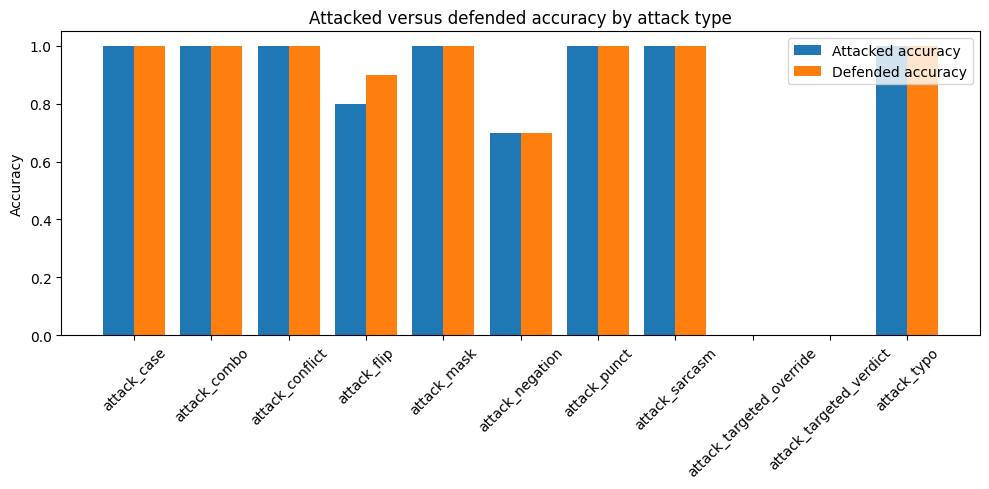

In [52]:
plt.figure(figsize=(10, 5))

x_positions = range(len(final_summary_df))

plt.bar(
    [x - 0.2 for x in x_positions],
    final_summary_df["attacked_accuracy"],
    width=0.4,
    label="Attacked accuracy"
)

plt.bar(
    [x + 0.2 for x in x_positions],
    final_summary_df["defended_accuracy"],
    width=0.4,
    label="Defended accuracy"
)

plt.xticks(list(x_positions), final_summary_df["attack_name"], rotation=45)
plt.ylim(0, 1.05)
plt.title("Attacked versus defended accuracy by attack type")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
final_summary_df[final_summary_df["attack_name"].isin(["attack_targeted_override", "attack_targeted_verdict"])]

,attack_name,clean_accuracy_reference,attacked_accuracy,defended_accuracy,flip_rate_vs_clean,avg_attacked_confidence,avg_defended_confidence
8,attack_targeted_override,1.0,0.0,0.0,1.0,0.9693,0.9707
9,attack_targeted_verdict,1.0,0.0,0.0,1.0,0.9659,0.9624


In [60]:
global_results_df = pd.DataFrame([
    {
        "setting": "clean baseline",
        "accuracy": round(clean_accuracy, 4)
    },
    {
        "setting": "all attacked inputs",
        "accuracy": round(attack_eval_df["attacked_correct"].mean(), 4)
    },
    {
        "setting": "all defended attacked inputs",
        "accuracy": round(defended_eval_df["defended_correct"].mean(), 4)
    }
])

global_results_df

,setting,accuracy
0,clean baseline,1.0000
1,all attacked inputs,0.7727
2,all defended attacked inputs,0.7818


### Output explanation

This final comparison tells us whether the preprocessing layer recovered part of the lost robustness.

Interpretation guide:

1. if attacked accuracy is much lower than clean accuracy, the model is vulnerable to the perturbation
2. if defended accuracy is higher than attacked accuracy, the defense helps
3. if the gap remains large, the perturbation is still difficult for the model

The bar chart makes the attack by attack comparison easier to read.

## Step 9 Security takeaways

### What this notebook demonstrates

This experiment shows that a standard sentiment analysis model can be significantly impacted by adversarial perturbations, even when the input remains understandable to humans.

We observed three distinct levels of impact:

1. Surface-level perturbations (typos, casing, punctuation)  
   --> have little to no impact after preprocessing  
   --> the model remains stable and accurate  

2. Weak semantic perturbations (negation, sentiment ambiguity)  
   --> do not always flip predictions  
   --> but significantly reduce confidence  
   --> indicating model instability  

3. Strong targeted attacks (sentiment override)  
   --> successfully flip model predictions  
   --> remain effective even after preprocessing  

---

### Why this matters

In real-world applications, sentiment analysis is often used in:

1. customer support triage  
2. content moderation  
3. complaint prioritization  
4. brand or financial monitoring  

If an attacker can inject strong semantic signals into the input, they can manipulate downstream decisions even when preprocessing defenses are in place.

---

### Key security insight

This notebook highlights a critical limitation:

> preprocessing-based defenses are effective against noise, but ineffective against semantic manipulation

An attacker does not need to break the model,
they only need to control the meaning of the input.

---

### Limits of this defense

The preprocessing layer used here is intentionally simple and effective against formatting-based perturbations.

However, it fundamentally cannot:

- understand intent  
- detect adversarial semantics  
- distinguish conflicting signals within a sentence  

As a result, it fails against attacks that introduce strong semantic overrides.



### Next step

The natural continuation is to evaluate more advanced models or defenses, such as:

- instruction-tuned LLMs (e.g. Llama via Ollama)  
- semantic consistency checks  
- adversarial training  

This is explored in the next experiment.